# Amazon Product Review Analysis and Recommendations

In [1]:
%%capture

#Silencing warnings, importing essential libraries, downloading necessary NLTK modules for text processing and sentiment analysis.

import warnings
warnings.filterwarnings("ignore")
import pandas as pa, numpy as nu, matplotlib.pyplot as dfa_vs, seaborn as se, os, seaborn, nltk
lmma = nltk.stem.WordNetLemmatizer()
modules_nltk=['punkt','wordnet','stopwords','omw-1.4']
for mdn in modules_nltk:
    nltk.download(mdn)

stop_words = set(nltk.corpus.stopwords.words('english'))
from textblob import TextBlob   
from sklearn import model_selection
from sklearn.feature_extraction import text

from sklearn import linear_model, tree, naive_bayes, ensemble, neighbors
from sklearn import feature_extraction, metrics
import pickle

## Data Reading

In [2]:
# Loading and inspecting dataset files, identifying categorical and numerical features.
def LoadDFAM(): 
    flavl=os.listdir(os.getcwd())
    for x in flavl:
        if "Datafiniti" in x or "Consumer_Reviews" in x or "Amazon" in x:
            loaded_zip=x
    dfam=pa.read_csv(loaded_zip,compression='zip') # Reading the CSV file inside the zip and storing it in 'dfam' dataframe
    print("Records: {}\nFeatures: {}".format(dfam.shape[0],dfam.shape[1]))
    catf=dfam.dtypes[dfam.dtypes=='object'].index.tolist()
    numf=dfam.dtypes[dfam.dtypes!='object'].index.tolist()
    print("-----------------------------------------")
    print("Available Categorical Features: {}\nAvailable Numerical Features: {}".format(len(catf),len(numf)))
    return dfam

In [3]:
# Load the dataset using LoadDFAM function and display the first 3 rows of the DataFrame.
DataAmazon=LoadDFAM()
DataAmazon.head(3)

Records: 28332
Features: 24
-----------------------------------------
Available Categorical Features: 21
Available Numerical Features: 3


,id,dateAdded,dateUpdated,name,asins,brand,categories,primaryCategories,imageURLs,keys,...,reviews.didPurchase,reviews.doRecommend,reviews.id,reviews.numHelpful,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.username,sourceURLs
0,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,NaN,3,https://www.amazon.com/product-reviews/B00QWO9...,I order 3 of them and one of the item is bad q...,... 3 of them and one of the item is bad quali...,Byger yang,"https://www.barcodable.com/upc/841710106442,ht..."
1,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,NaN,4,https://www.amazon.com/product-reviews/B00QWO9...,Bulk is always the less expensive way to go fo...,... always the less expensive way to go for pr...,ByMG,"https://www.barcodable.com/upc/841710106442,ht..."
2,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,NaN,5,https://www.amazon.com/product-reviews/B00QWO9...,Well they are not Duracell but for the price i...,... are not Duracell but for the price i am ha...,BySharon Lambert,"https://www.barcodable.com/upc/841710106442,ht..."


### Feature Investigation

In [4]:
# Investigating and handling missing values in the dataset by filling categorical missing values with mode and numerical missing values with mean.

def FetInvestigate(dfam):
    print("Details of Data Features\n")
    print(dfam.info())
    print("Missing Values Available in Data\n")
    print(dfam.isnull().sum())
    dfammissing=sum(dfam.isnull().sum())
    print("\nTotal Available Missing Values(Initially): {}".format(dfammissing))
    if dfammissing>0:
        catf=dfam.dtypes[dfam.dtypes=='object'].index.tolist()
        numf=dfam.dtypes[dfam.dtypes!='object'].index.tolist()
        for m in catf:
            dfam[m]=dfam[m].fillna(dfam[m].mode()[0])
        for n in numf:
            dfam[n]=dfam[n].fillna(dfam[n].mean())
    dfammissing1=sum(dfam.isnull().sum())
    print("\nTotal Available Missing Values(After Cleaning): {}".format(dfammissing1))
    print("Missing Values Status after Cleaning\n")
    print(dfam.isnull().sum())
    return dfam

In [5]:
# Apply the FetInvestigate function to clean missing values in the DataAmazon dataset and display the first few rows of the cleaned DataFrame.
Cln_DataAmazon=FetInvestigate(DataAmazon)
Cln_DataAmazon.head()

Details of Data Features

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28332 entries, 0 to 28331
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   28332 non-null  object 
 1   dateAdded            28332 non-null  object 
 2   dateUpdated          28332 non-null  object 
 3   name                 28332 non-null  object 
 4   asins                28332 non-null  object 
 5   brand                28332 non-null  object 
 6   categories           28332 non-null  object 
 7   primaryCategories    28332 non-null  object 
 8   imageURLs            28332 non-null  object 
 9   keys                 28332 non-null  object 
 10  manufacturer         28332 non-null  object 
 11  manufacturerNumber   28332 non-null  object 
 12  reviews.date         28332 non-null  object 
 13  reviews.dateSeen     28332 non-null  object 
 14  reviews.didPurchase  9 non-null      object 
 15  reviews.do

,id,dateAdded,dateUpdated,name,asins,brand,categories,primaryCategories,imageURLs,keys,...,reviews.didPurchase,reviews.doRecommend,reviews.id,reviews.numHelpful,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.username,sourceURLs
0,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,True,True,1.840066e+08,0.529321,3,https://www.amazon.com/product-reviews/B00QWO9...,I order 3 of them and one of the item is bad q...,... 3 of them and one of the item is bad quali...,Byger yang,"https://www.barcodable.com/upc/841710106442,ht..."
1,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,True,True,1.840066e+08,0.529321,4,https://www.amazon.com/product-reviews/B00QWO9...,Bulk is always the less expensive way to go fo...,... always the less expensive way to go for pr...,ByMG,"https://www.barcodable.com/upc/841710106442,ht..."
2,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,True,True,1.840066e+08,0.529321,5,https://www.amazon.com/product-reviews/B00QWO9...,Well they are not Duracell but for the price i...,... are not Duracell but for the price i am ha...,BySharon Lambert,"https://www.barcodable.com/upc/841710106442,ht..."
3,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,True,True,1.840066e+08,0.529321,5,https://www.amazon.com/product-reviews/B00QWO9...,Seem to work as well as name brand batteries a...,... as well as name brand batteries at a much ...,Bymark sexson,"https://www.barcodable.com/upc/841710106442,ht..."
4,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,True,True,1.840066e+08,0.529321,5,https://www.amazon.com/product-reviews/B00QWO9...,These batteries are very long lasting the pric...,... batteries are very long lasting the price ...,Bylinda,"https://www.barcodable.com/upc/841710106442,ht..."


### Feature Merging

In [6]:
# Concatenate two categorical features into a single feature if both are categorical, creating a new 'Review' feature from them.

def ConcatFet(dfam,f1,f2):
    scrh='Review'
    allwed='object'
    if dfam[f1].dtypes==allwed and dfam[f2].dtypes==allwed:
        print("Feature Merging Allowed")
        dfreview=Cln_DataAmazon[f1].tolist()
        dftitle=Cln_DataAmazon[f2].tolist()
        review_fin_fet=[]
        for x in range(len(dfreview)):
            review_fin_fet.append(dftitle[x]+' '+dfreview[x])
        if scrh in dfam.columns.tolist():
            dfam=dfam.drop('Review',axis=1)
        dfam[scrh]=review_fin_fet
        return dfam
    else:
        print("Both Feature are not Categorical, So, Merging Not Allowed")
        return dfam

In [7]:
# Merge the 'reviews.text' and 'reviews.title' features into a new 'Review' feature and display the first few rows of the updated DataFrame.

f1='reviews.text'
f2='reviews.title'
Cln_DataAmazon_1=ConcatFet(Cln_DataAmazon,f1,f2)
Cln_DataAmazon_1.head()

Feature Merging Allowed


,id,dateAdded,dateUpdated,name,asins,brand,categories,primaryCategories,imageURLs,keys,...,reviews.doRecommend,reviews.id,reviews.numHelpful,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.username,sourceURLs,Review
0,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,True,1.840066e+08,0.529321,3,https://www.amazon.com/product-reviews/B00QWO9...,I order 3 of them and one of the item is bad q...,... 3 of them and one of the item is bad quali...,Byger yang,"https://www.barcodable.com/upc/841710106442,ht...",... 3 of them and one of the item is bad quali...
1,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,True,1.840066e+08,0.529321,4,https://www.amazon.com/product-reviews/B00QWO9...,Bulk is always the less expensive way to go fo...,... always the less expensive way to go for pr...,ByMG,"https://www.barcodable.com/upc/841710106442,ht...",... always the less expensive way to go for pr...
2,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,True,1.840066e+08,0.529321,5,https://www.amazon.com/product-reviews/B00QWO9...,Well they are not Duracell but for the price i...,... are not Duracell but for the price i am ha...,BySharon Lambert,"https://www.barcodable.com/upc/841710106442,ht...",... are not Duracell but for the price i am ha...
3,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,True,1.840066e+08,0.529321,5,https://www.amazon.com/product-reviews/B00QWO9...,Seem to work as well as name brand batteries a...,... as well as name brand batteries at a much ...,Bymark sexson,"https://www.barcodable.com/upc/841710106442,ht...",... as well as name brand batteries at a much ...
4,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,True,1.840066e+08,0.529321,5,https://www.amazon.com/product-reviews/B00QWO9...,These batteries are very long lasting the pric...,... batteries are very long lasting the price ...,Bylinda,"https://www.barcodable.com/upc/841710106442,ht...",... batteries are very long lasting the price ...


## Text Analytics

### Text Cleaning

In [8]:
# Cleaning the 'Review' text feature by removing unwanted characters, stopwords, and performing lemmatization; then adding the cleaned text as a new 'Review_Cleaned' feature.

def Clean_Review_Text(DfAmaz):
    def LemText(txdthon):
        return  [lmma.lemmatize(t) for t in txdthon]
    def Clean_Row_Text(dfamrw):
        nltkstp = list(nltk.corpus.stopwords.words('english'))
        txt1=""
        wrdtodel=["rt","RT","http","HTTP","https","HTTPS","com","COM"]
        for d in dfamrw:
            if d.isalpha()==True:
                txt1+=d
            if d.isalnum()==False:
                pass
            if d==" " or d=="." or d=="," or d==";":
                txt1+=" "
        tkreview=str(txt1.lower()).split()
        tk2=[]
        for i in tkreview:
            if i not in wrdtodel:
                tk2.append(i)
        tk3=[]
        for i in tk2:
            if i not in nltkstp:
                tk3.append(i)
        tkjn=' '.join(tk3)
        tk3=tkjn.split()
        tk4=LemText(tk3)
        return ' '.join(tk4)
    RevTextClean=[]
    TxtReview=DfAmaz["Review"].tolist()
    for i in TxtReview:
        RevTextClean.append(Clean_Row_Text(i))
    DfAmaz['Review_Cleaned']=RevTextClean
    return DfAmaz
TxCln_DataAmazon=Clean_Review_Text(Cln_DataAmazon_1)
TxCln_DataAmazon.head(3)

,id,dateAdded,dateUpdated,name,asins,brand,categories,primaryCategories,imageURLs,keys,...,reviews.id,reviews.numHelpful,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.username,sourceURLs,Review,Review_Cleaned
0,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,1.840066e+08,0.529321,3,https://www.amazon.com/product-reviews/B00QWO9...,I order 3 of them and one of the item is bad q...,... 3 of them and one of the item is bad quali...,Byger yang,"https://www.barcodable.com/upc/841710106442,ht...",... 3 of them and one of the item is bad quali...,one item bad quality missing backup spring ord...
1,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,1.840066e+08,0.529321,4,https://www.amazon.com/product-reviews/B00QWO9...,Bulk is always the less expensive way to go fo...,... always the less expensive way to go for pr...,ByMG,"https://www.barcodable.com/upc/841710106442,ht...",... always the less expensive way to go for pr...,always le expensive way go product like bulk a...
2,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,1.840066e+08,0.529321,5,https://www.amazon.com/product-reviews/B00QWO9...,Well they are not Duracell but for the price i...,... are not Duracell but for the price i am ha...,BySharon Lambert,"https://www.barcodable.com/upc/841710106442,ht...",... are not Duracell but for the price i am ha...,duracell price happy well duracell price happy


In [9]:
TxCln_DataAmazon[['Review','Review_Cleaned']]

,Review,Review_Cleaned
0,... 3 of them and one of the item is bad quali...,one item bad quality missing backup spring ord...
1,... always the less expensive way to go for pr...,always le expensive way go product like bulk a...
2,... are not Duracell but for the price i am ha...,duracell price happy well duracell price happy
3,... as well as name brand batteries at a much ...,well name brand battery much better seem work ...
4,... batteries are very long lasting the price ...,battery long lasting price great battery long ...
...,...,...
28327,Xmas gift I got 2 of these for my 8 yr old twi...,xmas gift got yr old twin yr old one one bette...
28328,yes it is a great tablet. I bought this for my...,yes great tablet bought niece christmas gift y...
28329,You get a lot for the price! Very nice for lig...,get lot price nice light internet browsing kee...
28330,You get the entire World for less than $100! T...,get entire world le tablet absolutely everythi...


### Data Visualization

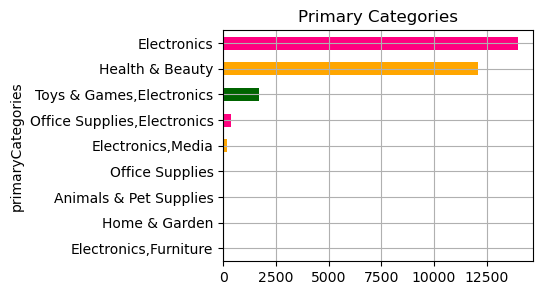

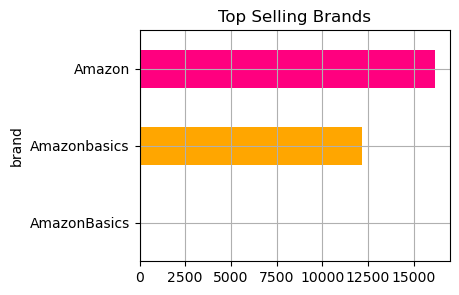

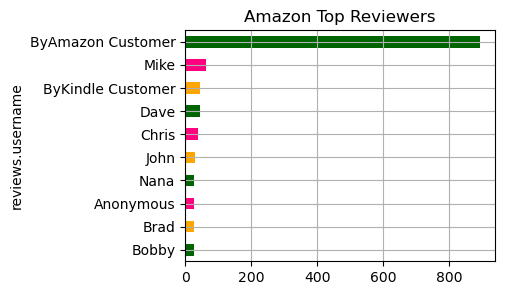

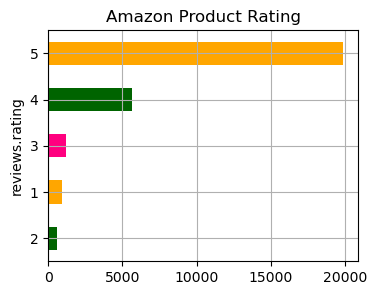

In [10]:
# Plot horizontal bar charts for the top 10 values of selected features, with customized titles, colors, and grid settings.

knd='barh'
fets=['primaryCategories','brand','reviews.username','reviews.rating']
grphttl=["Primary Categories","Top Selling Brands","Amazon Top Reviewers",'Amazon Product Rating']
fsz=(4,3)
clsq=["#006400","#FFA600","#FF007F"]
for f in range(len(fets)):
    TxCln_DataAmazon[fets[f]].value_counts().iloc[:10][::-1].plot(kind=knd,title=grphttl[f], figsize=fsz, color=clsq)
    dfa_vs.grid()
    dfa_vs.show()

### Subsetting Data

In [11]:
# Select and display specific columns from the cleaned DataFrame for further analysis.

TxCln_DataAmazon1=TxCln_DataAmazon[["Review","Review_Cleaned","categories","primaryCategories","imageURLs","reviews.rating","reviews.sourceURLs"]]
TxCln_DataAmazon1.head()
TxCln_DataAmazon1.to_csv("subset_data_amazon.csv", index=False)

### Sentiment Extraction

In [12]:
# Analyze sentiment of cleaned reviews using TextBlob, classify them as Positive, Negative, or Neutral, and add the results to the DataFrame.

ReviewTxt=TxCln_DataAmazon1['Review_Cleaned'].tolist()
polarity_review=[]
sentiment_products=[]
for i in ReviewTxt:
    sent_rv=TextBlob(str(i)).sentiment
    polarity_review.append(sent_rv[0])
for i in range(len(polarity_review)):
    if polarity_review[i]>0:
        sentiment_products.append("Positive")
    elif polarity_review[i]<0:
        sentiment_products.append("Negative")
    else:
        sentiment_products.append("Neutral")
TxCln_DataAmazon1['Polarity']=polarity_review
TxCln_DataAmazon1['Sentiment']=sentiment_products
TxCln_DataAmazon1=TxCln_DataAmazon1.reset_index(drop=True)
TxCln_DataAmazon1.head(10)

,Review,Review_Cleaned,categories,primaryCategories,imageURLs,reviews.rating,reviews.sourceURLs,Polarity,Sentiment
0,... 3 of them and one of the item is bad quali...,one item bad quality missing backup spring ord...,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,3,https://www.amazon.com/product-reviews/B00QWO9...,-0.450000,Negative
1,... always the less expensive way to go for pr...,always le expensive way go product like bulk a...,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,4,https://www.amazon.com/product-reviews/B00QWO9...,-0.500000,Negative
2,... are not Duracell but for the price i am ha...,duracell price happy well duracell price happy,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,5,https://www.amazon.com/product-reviews/B00QWO9...,0.800000,Positive
3,... as well as name brand batteries at a much ...,well name brand battery much better seem work ...,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,5,https://www.amazon.com/product-reviews/B00QWO9...,0.500000,Positive
4,... batteries are very long lasting the price ...,battery long lasting price great battery long ...,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,5,https://www.amazon.com/product-reviews/B00QWO9...,0.250000,Positive
5,... batteries for Christmas and the AmazonBasi...,battery christmas amazonbasics cell good haven...,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,5,https://www.amazon.com/product-reviews/B00QWO9...,0.466667,Positive
6,... batteries have ordered them in the past be...,battery ordered past pleased ive problame batt...,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,5,https://www.amazon.com/product-reviews/B00QWO9...,0.125000,Positive
7,... batteries that last quite a while then the...,battery last quite perfect nothing say well lo...,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,5,https://www.amazon.com/product-reviews/B00QWO9...,0.480000,Positive
8,... do not hold the amount of high power juice...,hold amount high power juice like energizer du...,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,3,https://www.amazon.com/product-reviews/B00QWO9...,0.051111,Positive
9,... done well by me appear to have a good shel...,done well appear good shelf life amazonbasics ...,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,4,https://www.amazon.com/product-reviews/B00QWO9...,0.300000,Positive


In [13]:
# Count and display the distribution of sentiment categories (Positive, Negative, Neutral) in the DataFrame.

TxCln_DataAmazon1['Sentiment'].value_counts()

Sentiment
Positive    25198
Negative     1613
Neutral      1521
Name: count, dtype: int64

## Data Prepration

### Data Split

In [14]:
# Split the data into training and testing sets, then display the distribution of sentiment labels in both sets.

data=TxCln_DataAmazon1.copy()
X=data['Review_Cleaned']
y=data['Sentiment']
DtXTrn,DtXTst,DtyTrn,DtyTst=model_selection.train_test_split(X,y,train_size=0.8,random_state=22)
print(DtyTst.value_counts())
print(DtyTrn.value_counts())

Sentiment
Positive    5027
Negative     324
Neutral      316
Name: count, dtype: int64
Sentiment
Positive    20171
Negative     1289
Neutral      1205
Name: count, dtype: int64


### Assigning Classifiers

In [15]:
# Define a list of machine learning models and their corresponding names for sentiment classification.

MdAmz=[
    linear_model.LogisticRegression(), 
    tree.DecisionTreeClassifier(),
    naive_bayes.MultinomialNB(),
    ensemble.RandomForestClassifier(),
    neighbors.KNeighborsClassifier()
]

ClAmz=[
    "Logistic Regression ",
    "Decision Tree",
    "Multinomial Naïve Bayes",
    "Random Forest",
    "K-Nearest Neighbours"
]

### Feature Extraction

In [16]:
# Defining and applying functions for TF-IDF and Count Vectorizer feature extraction on training and testing data.

def Func_TFIDF(DtXTrn,DtXTst):
    print("~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")
    print("                 Feature Extraction using TFIDF")
    print("~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")
    TrDtTf=[]
    TsDtTf=[]
    ngs_val=["Unigram","Bigram"]
    for i in range(2):
        FETFIDF=feature_extraction.text.TfidfVectorizer(stop_words='english', analyzer='word',max_df=0.7,ngram_range=(i+1,i+1))
        TrDtTf.append(FETFIDF.fit_transform(DtXTrn))
        TsDtTf.append(FETFIDF.transform(DtXTst))
        print("Total Extracted Features in Vectorised Data for {} TFIDF: {}".format(ngs_val[i],TrDtTf[i].shape[1]))
    return TrDtTf,TsDtTf
def Func_BOW(DtXTrn,DtXTst):
    TrDtBOW=[]
    TsDtBOW=[]
    print("\n")
    print("~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")
    print("                Feature Extraction using Count Vectorizer")
    print("~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")
    ngs_val=["Unigram","Bigram"]
    for i in range(2):
        FECV=feature_extraction.text.CountVectorizer(stop_words='english', analyzer='word',max_df=0.7,ngram_range=(i+1,i+1))
        TrDtBOW.append(FECV.fit_transform(DtXTrn))
        TsDtBOW.append(FECV.transform(DtXTst))
        print("Total Extracted Features in Vectorised Data for {} CV: {}".format(ngs_val[i],TrDtBOW[i].shape[1]))
    return TrDtBOW,TsDtBOW

TrDtTf,TsDtTf=Func_TFIDF(DtXTrn,DtXTst) # Applying TF-IDF vectorization to the training and test data
TrDtBOW,TsDtBOW=Func_BOW(DtXTrn,DtXTst) # Applying BoW vectorization to the training and test data


~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
                 Feature Extraction using TFIDF
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Total Extracted Features in Vectorised Data for Unigram TFIDF: 8955
Total Extracted Features in Vectorised Data for Bigram TFIDF: 95559


~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
                Feature Extraction using Count Vectorizer
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Total Extracted Features in Vectorised Data for Unigram CV: 8955
Total Extracted Features in Vectorised Data for Bigram CV: 95559


## Sentiment Detection

### Sentiment Detection Using TFIDF (Uni+Bi)

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
                       TFIDF + Unigram
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
________________________________________________________________________
               Logistic Regression  with Unigram
________________________________________________________________________


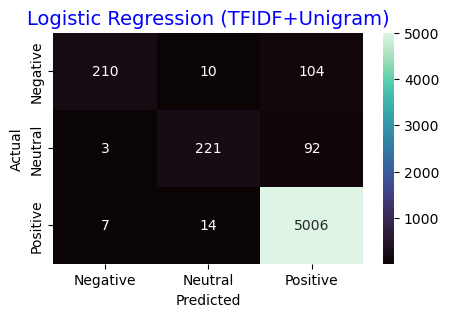

              precision    recall  f1-score   support

    Negative       0.95      0.65      0.77       324
     Neutral       0.90      0.70      0.79       316
    Positive       0.96      1.00      0.98      5027

    accuracy                           0.96      5667
   macro avg       0.94      0.78      0.85      5667
weighted avg       0.96      0.96      0.96      5667

Accuracy : 95.94%
Precision : 95.85000000000001%
Recall : 95.94%
F1-Score : 95.63000000000001%
Correct Detection:5437
Correct Detection Rate: 95.9414%
Error:230
Wrong Detection Rate: 4.0586%
________________________________________________________________________
               Decision Tree with Unigram
________________________________________________________________________


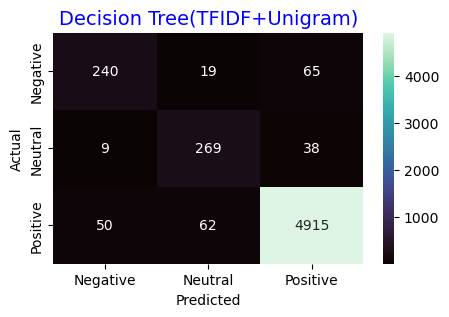

              precision    recall  f1-score   support

    Negative       0.80      0.74      0.77       324
     Neutral       0.77      0.85      0.81       316
    Positive       0.98      0.98      0.98      5027

    accuracy                           0.96      5667
   macro avg       0.85      0.86      0.85      5667
weighted avg       0.96      0.96      0.96      5667

Accuracy : 95.71%
Precision : 95.76%
Recall : 95.71%
F1-Score : 95.72%
Correct Detection:5424
Correct Detection Rate: 95.712%
Error:243
Wrong Detection Rate: 4.288%
________________________________________________________________________
               Multinomial Naïve Bayes with Unigram
________________________________________________________________________


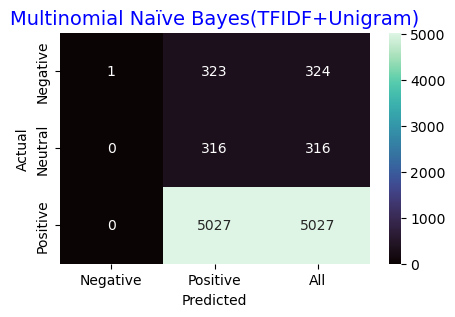

              precision    recall  f1-score   support

    Negative       1.00      0.00      0.01       324
     Neutral       0.00      0.00      0.00       316
    Positive       0.89      1.00      0.94      5027

    accuracy                           0.89      5667
   macro avg       0.63      0.33      0.32      5667
weighted avg       0.84      0.89      0.83      5667

Accuracy : 88.72%
Precision : 84.42%
Recall : 88.72%
F1-Score : 83.44%
Correct Detection:5344
Correct Detection Rate: 47.1502%
Error:5990
Wrong Detection Rate: 52.8498%
________________________________________________________________________
               Random Forest with Unigram
________________________________________________________________________


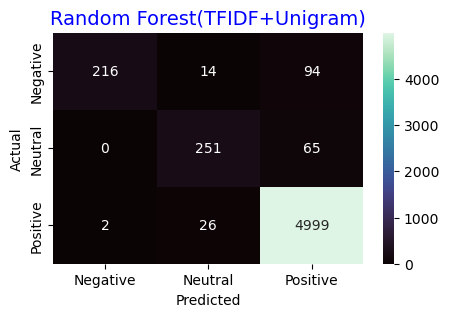

              precision    recall  f1-score   support

    Negative       0.99      0.67      0.80       324
     Neutral       0.86      0.79      0.83       316
    Positive       0.97      0.99      0.98      5027

    accuracy                           0.96      5667
   macro avg       0.94      0.82      0.87      5667
weighted avg       0.96      0.96      0.96      5667

Accuracy : 96.45%
Precision : 96.45%
Recall : 96.45%
F1-Score : 96.25%
Correct Detection:5466
Correct Detection Rate: 96.4531%
Error:201
Wrong Detection Rate: 3.5469%
________________________________________________________________________
               K-Nearest Neighbours with Unigram
________________________________________________________________________


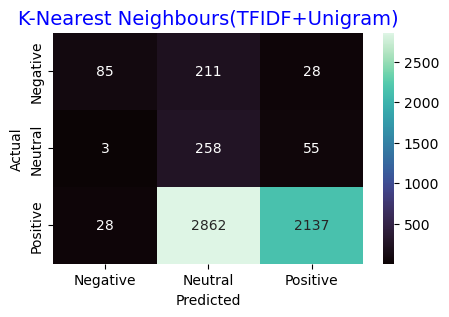

              precision    recall  f1-score   support

    Negative       0.73      0.26      0.39       324
     Neutral       0.08      0.82      0.14       316
    Positive       0.96      0.43      0.59      5027

    accuracy                           0.44      5667
   macro avg       0.59      0.50      0.37      5667
weighted avg       0.90      0.44      0.55      5667

Accuracy : 43.76%
Precision : 90.01%
Recall : 43.76%
F1-Score : 55.31%
Correct Detection:2480
Correct Detection Rate: 43.7621%
Error:3187
Wrong Detection Rate: 56.2379%
________________________________________________________________________
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
                       TFIDF + Bigram
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
________________________________________________________________________
               Logistic Regression  with Bigram
________________________________________________________________________

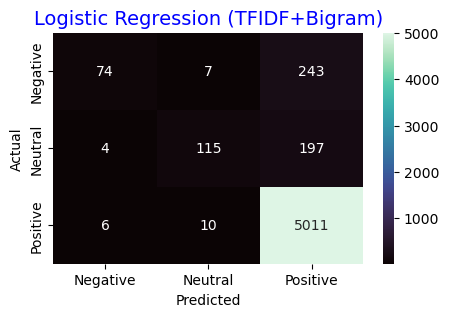

              precision    recall  f1-score   support

    Negative       0.88      0.23      0.36       324
     Neutral       0.87      0.36      0.51       316
    Positive       0.92      1.00      0.96      5027

    accuracy                           0.92      5667
   macro avg       0.89      0.53      0.61      5667
weighted avg       0.91      0.92      0.90      5667

Accuracy : 91.75999999999999%
Precision : 91.44%
Recall : 91.75999999999999%
F1-Score : 89.78%
Correct Detection:5200
Correct Detection Rate: 91.7593%
Error:467
Wrong Detection Rate: 8.2407%
________________________________________________________________________
               Decision Tree with Bigram
________________________________________________________________________


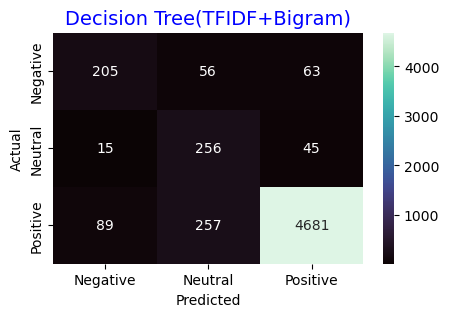

              precision    recall  f1-score   support

    Negative       0.66      0.63      0.65       324
     Neutral       0.45      0.81      0.58       316
    Positive       0.98      0.93      0.95      5027

    accuracy                           0.91      5667
   macro avg       0.70      0.79      0.73      5667
weighted avg       0.93      0.91      0.92      5667

Accuracy : 90.74%
Precision : 93.01%
Recall : 90.74%
F1-Score : 91.53%
Correct Detection:5142
Correct Detection Rate: 90.7358%
Error:525
Wrong Detection Rate: 9.2642%
________________________________________________________________________
               Multinomial Naïve Bayes with Bigram
________________________________________________________________________


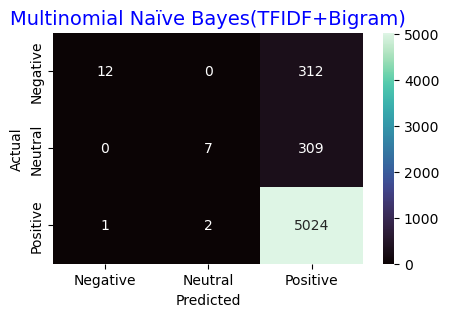

              precision    recall  f1-score   support

    Negative       0.92      0.04      0.07       324
     Neutral       0.78      0.02      0.04       316
    Positive       0.89      1.00      0.94      5027

    accuracy                           0.89      5667
   macro avg       0.86      0.35      0.35      5667
weighted avg       0.89      0.89      0.84      5667

Accuracy : 88.99000000000001%
Precision : 88.56%
Recall : 88.99000000000001%
F1-Score : 84.17%
Correct Detection:5043
Correct Detection Rate: 88.9889%
Error:624
Wrong Detection Rate: 11.0111%
________________________________________________________________________
               Random Forest with Bigram
________________________________________________________________________


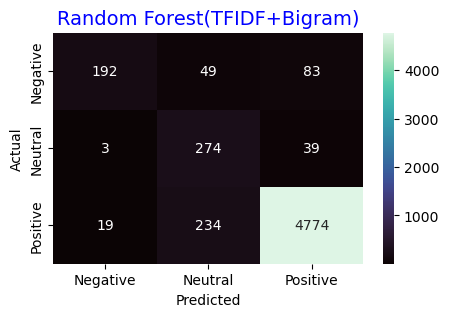

              precision    recall  f1-score   support

    Negative       0.90      0.59      0.71       324
     Neutral       0.49      0.87      0.63       316
    Positive       0.98      0.95      0.96      5027

    accuracy                           0.92      5667
   macro avg       0.79      0.80      0.77      5667
weighted avg       0.94      0.92      0.93      5667

Accuracy : 92.47%
Precision : 94.37%
Recall : 92.47%
F1-Score : 92.94%
Correct Detection:5240
Correct Detection Rate: 92.4651%
Error:427
Wrong Detection Rate: 7.5349%
________________________________________________________________________
               K-Nearest Neighbours with Bigram
________________________________________________________________________


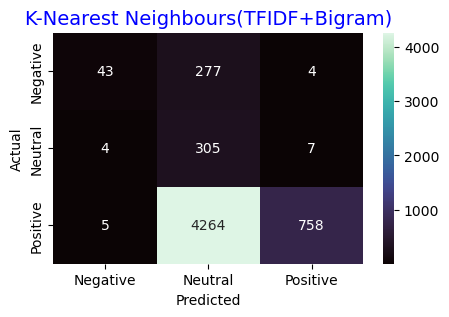

              precision    recall  f1-score   support

    Negative       0.83      0.13      0.23       324
     Neutral       0.06      0.97      0.12       316
    Positive       0.99      0.15      0.26      5027

    accuracy                           0.20      5667
   macro avg       0.63      0.42      0.20      5667
weighted avg       0.93      0.20      0.25      5667

Accuracy : 19.52%
Precision : 92.52%
Recall : 19.52%
F1-Score : 25.169999999999998%
Correct Detection:1106
Correct Detection Rate: 19.5165%
Error:4561
Wrong Detection Rate: 80.4835%
________________________________________________________________________


In [17]:
# Evaluate and display performance metrics and confusion matrices for different models using TF-IDF features, with results visualized as heatmaps.

ResMtTFAmz=[[[],[],[],[],[],[]],[[],[],[],[],[],[]]] # Initializing lists to store results for each model and vectorization type
ngs_val=["Unigram","Bigram"]
mts_avg="weighted"
ptvl=4
for tlp in range(len(TrDtTf)):
    print("~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")
    print("                       TFIDF + {}".format(ngs_val[tlp]))
    print("~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")
    print("________________________________________________________________________")
    for i in range(len(MdAmz)):
        print("               {} with {}".format(ClAmz[i],ngs_val[tlp]))
        print("________________________________________________________________________")
        MdTf = MdAmz[i]
        MdTf.fit(TrDtTf[tlp], DtyTrn)
        resprtf=MdTf.predict(TsDtTf[tlp])
        AccTfTst=round(metrics.accuracy_score(DtyTst,resprtf),ptvl)*100
        ResMtTFAmz[tlp][0].append(AccTfTst)
        ResMtTFAmz[tlp][1].append(round(metrics.precision_score(DtyTst,resprtf,average=mts_avg),ptvl)*100)      
        ResMtTFAmz[tlp][2].append(round(metrics.recall_score(DtyTst,resprtf,average=mts_avg),ptvl)*100)
        ResMtTFAmz[tlp][3].append(round(metrics.f1_score(DtyTst,resprtf,average=mts_avg),ptvl)*100)
        ct=pa.crosstab(DtyTst, resprtf, rownames=['Actual'], colnames=['Predicted'], margins=True)    
        ResMtTFAmz[tlp][4].append(ct)
        dfa_vs.figure(figsize=(5,3))
        dfa_vs.title("{}(TFIDF+{})".format(ClAmz[i],ngs_val[tlp]),fontsize=14,color="b")
        se.heatmap(ct.iloc[:3,:3],annot=True,cmap="mako",fmt="d")
        dfa_vs.show()
        p=round(metrics.precision_score(DtyTst,resprtf,average=mts_avg),ptvl)*100
        r=round(metrics.recall_score(DtyTst,resprtf,average=mts_avg),ptvl)*100
        f=round(metrics.f1_score(DtyTst,resprtf,average=mts_avg),ptvl)*100
        ResMtTFAmz[tlp][5].append(metrics.classification_report(DtyTst, resprtf))
        print(metrics.classification_report(DtyTst, resprtf))
        print("Accuracy : {}%\nPrecision : {}%".format(AccTfTst,p))
        print("Recall : {}%\nF1-Score : {}%".format(r,f))
        cnfcl=ct.iloc[:3,:3].to_numpy()
        vlsm=sum(sum(cnfcl))
        crtvl=sum(cnfcl.diagonal())
        wrongvl=vlsm-crtvl
        print("Correct Detection:{}\nCorrect Detection Rate: {}%\nError:{}\nWrong Detection Rate: {}%".format(crtvl,round(crtvl/vlsm*100,4),wrongvl,round(wrongvl/vlsm*100,4)))
        print("________________________________________________________________________")
        

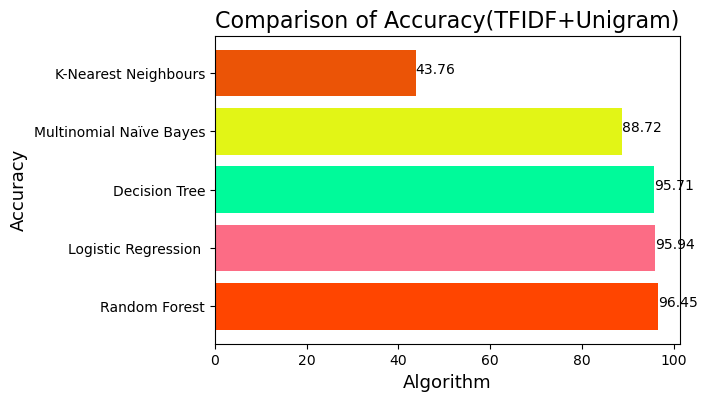

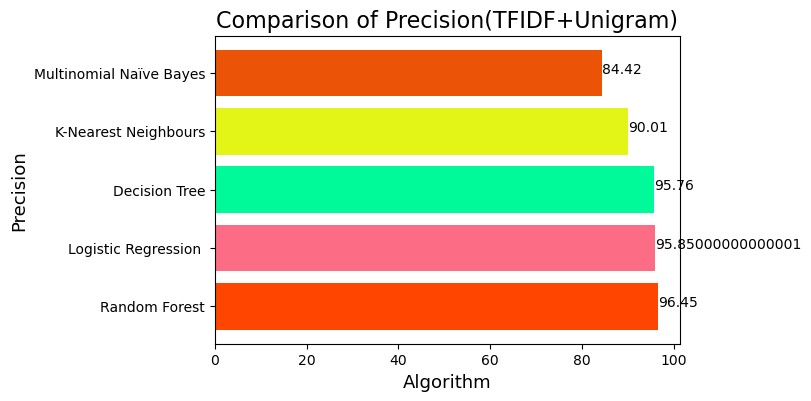

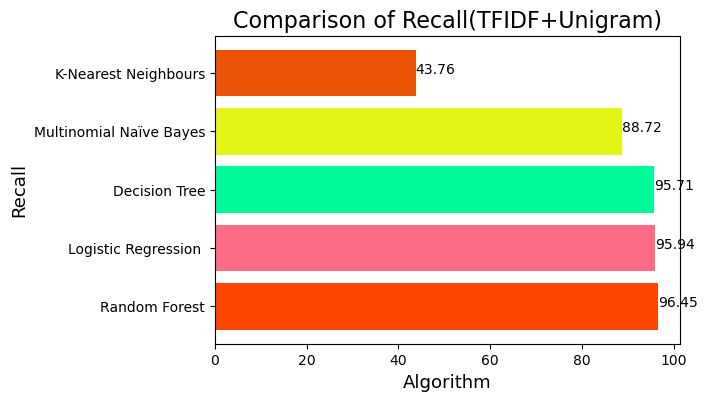

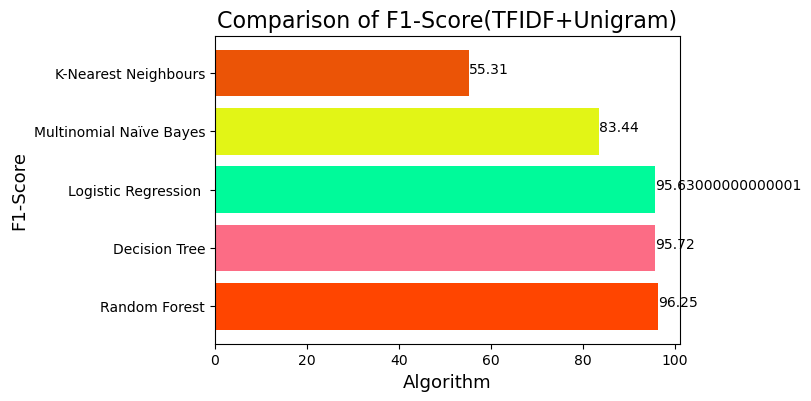

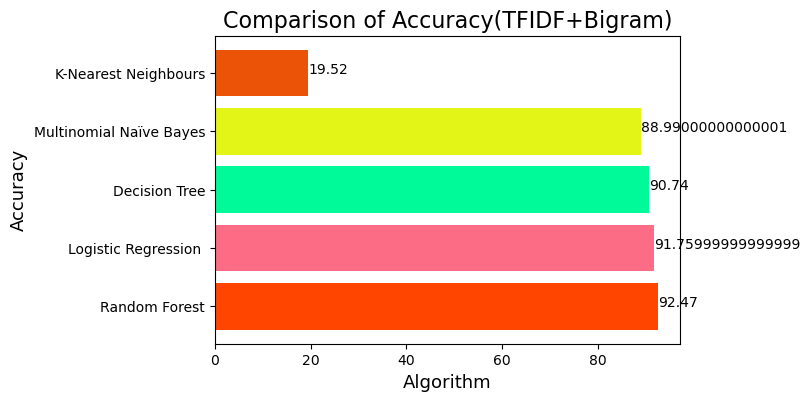

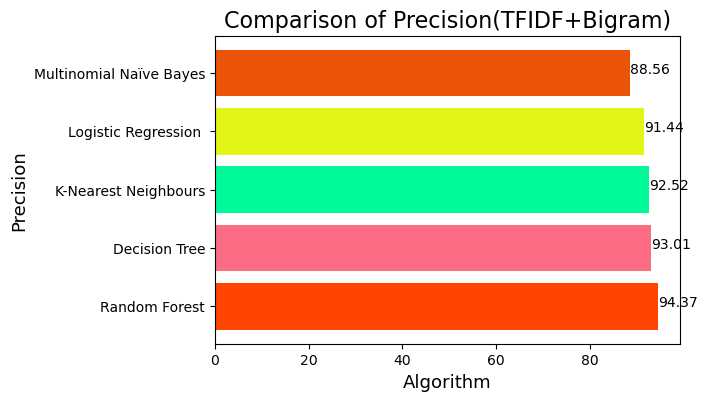

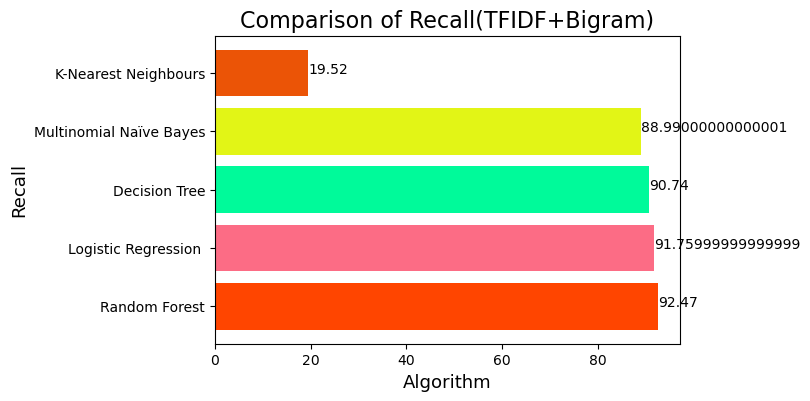

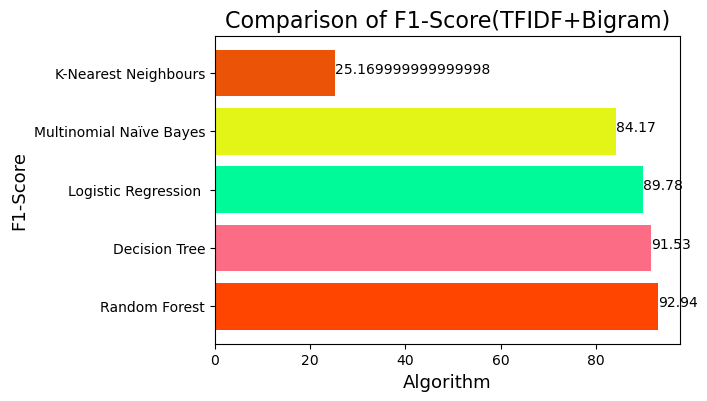

In [18]:
# Create and display bar charts comparing model performance metrics for different algorithms using TF-IDF features; save the results to CSV files.

AllTFDf=[]
for i in range(2):
    DfAmTf=pa.DataFrame({
        "Algorithm":ClAmz,
        "Accuracy":ResMtTFAmz[i][0],
        "Precision":ResMtTFAmz[i][1],
        "Recall":ResMtTFAmz[i][2],
        "F1-Score":ResMtTFAmz[i][3]
    })
    AllTFDf.append(DfAmTf)
    plt_cols=DfAmTf.columns.tolist()[1:]
    for x in plt_cols:
        DfAmTf=DfAmTf.sort_values(by=x,ascending=False)
        dfa_vs.figure(figsize=(6,4))
        dfa_vs.title("Comparison of {}(TFIDF+{})".format(x,ngs_val[i]),fontsize=16)
        dfa_vs.barh(DfAmTf['Algorithm'],DfAmTf[x],color=["#FF4500","#FC6C85","#00FA9A","#E2F516","#EB5406"])
        dfa_vs.xlabel("Algorithm",fontsize=13)
        dfa_vs.ylabel("{}".format(x),fontsize=13)
        for tfid, tfvl in enumerate(DfAmTf[x]):
            dfa_vs.text(tfvl, tfid, str(tfvl))
        dfa_vs.show()
    DfAmTf.sort_values(by="Accuracy",ascending=False).to_csv("{}_TFIDF.csv".format(ngs_val[i]))


In [19]:
AllTFDf[0]

,Algorithm,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,95.94,95.85,95.94,95.63
1,Decision Tree,95.71,95.76,95.71,95.72
2,Multinomial Naïve Bayes,88.72,84.42,88.72,83.44
3,Random Forest,96.45,96.45,96.45,96.25
4,K-Nearest Neighbours,43.76,90.01,43.76,55.31


In [20]:
AllTFDf[1]

,Algorithm,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,91.76,91.44,91.76,89.78
1,Decision Tree,90.74,93.01,90.74,91.53
2,Multinomial Naïve Bayes,88.99,88.56,88.99,84.17
3,Random Forest,92.47,94.37,92.47,92.94
4,K-Nearest Neighbours,19.52,92.52,19.52,25.17


### Sentiment Detection Using Bag-of-Words (Uni+Bi)

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
                       Bag-of-Words + Unigram
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
________________________________________________________________________
               Logistic Regression  with Unigram
________________________________________________________________________


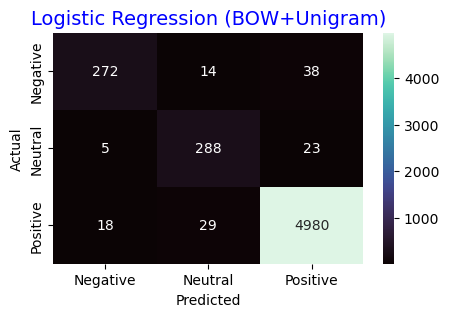

              precision    recall  f1-score   support

    Negative       0.92      0.84      0.88       324
     Neutral       0.87      0.91      0.89       316
    Positive       0.99      0.99      0.99      5027

    accuracy                           0.98      5667
   macro avg       0.93      0.91      0.92      5667
weighted avg       0.98      0.98      0.98      5667

Accuracy : 97.76%
Precision : 97.76%
Recall : 97.76%
F1-Score : 97.74000000000001%
Correct Detection:5540
Correct Detection Rate: 97.759%
Error:127
Wrong Detection Rate: 2.241%
________________________________________________________________________
               Decision Tree with Unigram
________________________________________________________________________


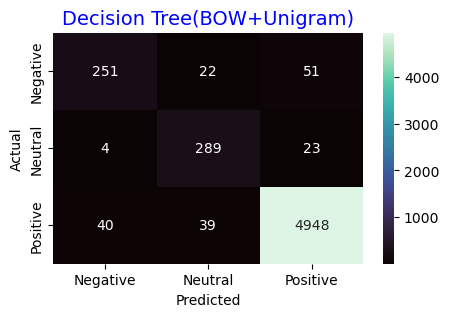

              precision    recall  f1-score   support

    Negative       0.85      0.77      0.81       324
     Neutral       0.83      0.91      0.87       316
    Positive       0.99      0.98      0.98      5027

    accuracy                           0.97      5667
   macro avg       0.89      0.89      0.89      5667
weighted avg       0.97      0.97      0.97      5667

Accuracy : 96.84%
Precision : 96.87%
Recall : 96.84%
F1-Score : 96.83%
Correct Detection:5488
Correct Detection Rate: 96.8414%
Error:179
Wrong Detection Rate: 3.1586%
________________________________________________________________________
               Multinomial Naïve Bayes with Unigram
________________________________________________________________________


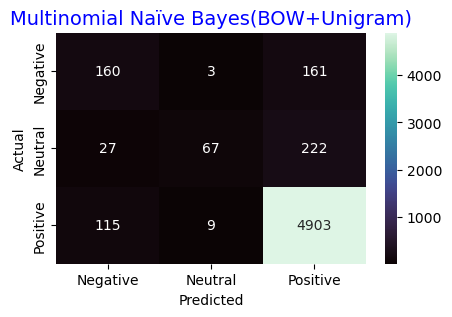

              precision    recall  f1-score   support

    Negative       0.53      0.49      0.51       324
     Neutral       0.85      0.21      0.34       316
    Positive       0.93      0.98      0.95      5027

    accuracy                           0.91      5667
   macro avg       0.77      0.56      0.60      5667
weighted avg       0.90      0.91      0.89      5667

Accuracy : 90.52%
Precision : 90.03999999999999%
Recall : 90.52%
F1-Score : 89.16%
Correct Detection:5130
Correct Detection Rate: 90.5241%
Error:537
Wrong Detection Rate: 9.4759%
________________________________________________________________________
               Random Forest with Unigram
________________________________________________________________________


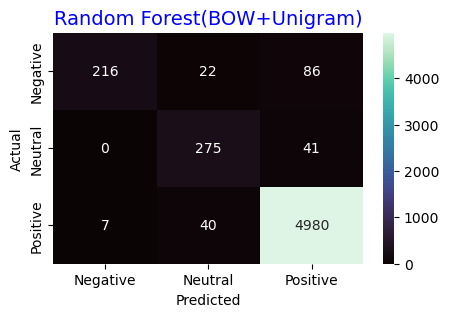

              precision    recall  f1-score   support

    Negative       0.97      0.67      0.79       324
     Neutral       0.82      0.87      0.84       316
    Positive       0.98      0.99      0.98      5027

    accuracy                           0.97      5667
   macro avg       0.92      0.84      0.87      5667
weighted avg       0.97      0.97      0.96      5667

Accuracy : 96.54%
Precision : 96.59%
Recall : 96.54%
F1-Score : 96.39999999999999%
Correct Detection:5471
Correct Detection Rate: 96.5414%
Error:196
Wrong Detection Rate: 3.4586%
________________________________________________________________________
               K-Nearest Neighbours with Unigram
________________________________________________________________________


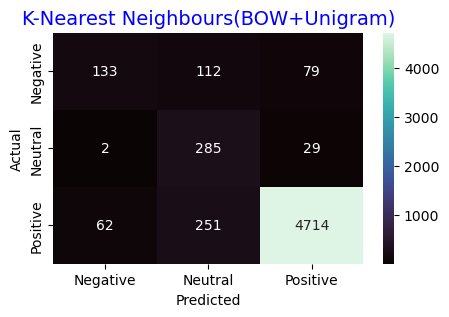

              precision    recall  f1-score   support

    Negative       0.68      0.41      0.51       324
     Neutral       0.44      0.90      0.59       316
    Positive       0.98      0.94      0.96      5027

    accuracy                           0.91      5667
   macro avg       0.70      0.75      0.69      5667
weighted avg       0.93      0.91      0.91      5667

Accuracy : 90.56%
Precision : 93.03%
Recall : 90.56%
F1-Score : 91.13%
Correct Detection:5132
Correct Detection Rate: 90.5594%
Error:535
Wrong Detection Rate: 9.4406%
________________________________________________________________________
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
                       Bag-of-Words + Bigram
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
________________________________________________________________________
               Logistic Regression  with Bigram
___________________________________________________________________

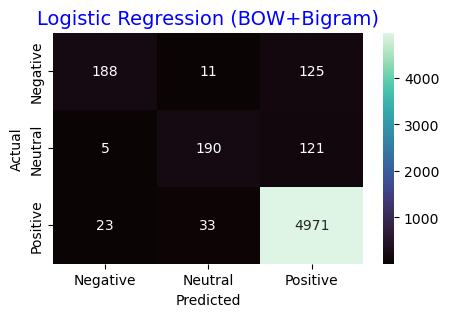

              precision    recall  f1-score   support

    Negative       0.87      0.58      0.70       324
     Neutral       0.81      0.60      0.69       316
    Positive       0.95      0.99      0.97      5027

    accuracy                           0.94      5667
   macro avg       0.88      0.72      0.79      5667
weighted avg       0.94      0.94      0.94      5667

Accuracy : 94.39%
Precision : 94.03%
Recall : 94.39%
F1-Score : 93.92%
Correct Detection:5349
Correct Detection Rate: 94.3886%
Error:318
Wrong Detection Rate: 5.6114%
________________________________________________________________________
               Decision Tree with Bigram
________________________________________________________________________


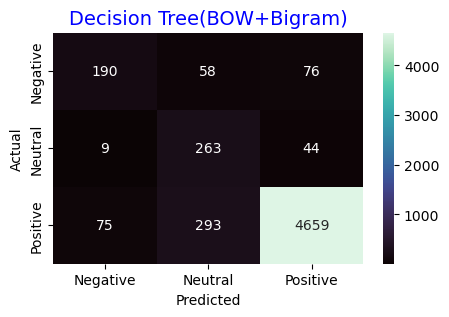

              precision    recall  f1-score   support

    Negative       0.69      0.59      0.64       324
     Neutral       0.43      0.83      0.57       316
    Positive       0.97      0.93      0.95      5027

    accuracy                           0.90      5667
   macro avg       0.70      0.78      0.72      5667
weighted avg       0.93      0.90      0.91      5667

Accuracy : 90.21000000000001%
Precision : 92.83%
Recall : 90.21000000000001%
F1-Score : 91.08000000000001%
Correct Detection:5112
Correct Detection Rate: 90.2065%
Error:555
Wrong Detection Rate: 9.7935%
________________________________________________________________________
               Multinomial Naïve Bayes with Bigram
________________________________________________________________________


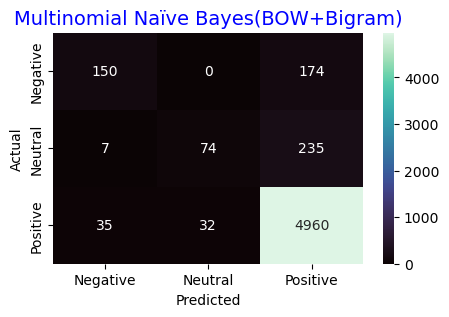

              precision    recall  f1-score   support

    Negative       0.78      0.46      0.58       324
     Neutral       0.70      0.23      0.35       316
    Positive       0.92      0.99      0.95      5027

    accuracy                           0.91      5667
   macro avg       0.80      0.56      0.63      5667
weighted avg       0.90      0.91      0.90      5667

Accuracy : 91.47999999999999%
Precision : 90.31%
Recall : 91.47999999999999%
F1-Score : 89.92%
Correct Detection:5184
Correct Detection Rate: 91.477%
Error:483
Wrong Detection Rate: 8.523%
________________________________________________________________________
               Random Forest with Bigram
________________________________________________________________________


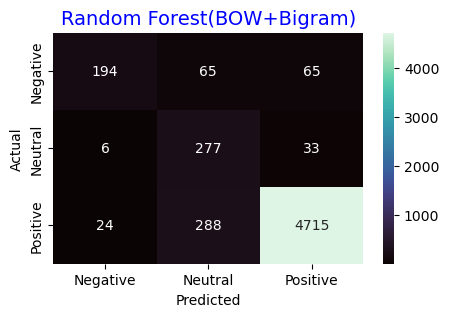

              precision    recall  f1-score   support

    Negative       0.87      0.60      0.71       324
     Neutral       0.44      0.88      0.59       316
    Positive       0.98      0.94      0.96      5027

    accuracy                           0.92      5667
   macro avg       0.76      0.80      0.75      5667
weighted avg       0.94      0.92      0.92      5667

Accuracy : 91.51%
Precision : 94.3%
Recall : 91.51%
F1-Score : 92.32000000000001%
Correct Detection:5186
Correct Detection Rate: 91.5123%
Error:481
Wrong Detection Rate: 8.4877%
________________________________________________________________________
               K-Nearest Neighbours with Bigram
________________________________________________________________________


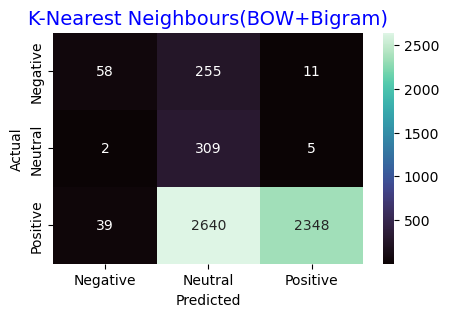

              precision    recall  f1-score   support

    Negative       0.59      0.18      0.27       324
     Neutral       0.10      0.98      0.18       316
    Positive       0.99      0.47      0.64      5027

    accuracy                           0.48      5667
   macro avg       0.56      0.54      0.36      5667
weighted avg       0.92      0.48      0.59      5667

Accuracy : 47.910000000000004%
Precision : 91.99000000000001%
Recall : 47.910000000000004%
F1-Score : 58.91%
Correct Detection:2715
Correct Detection Rate: 47.9089%
Error:2952
Wrong Detection Rate: 52.0911%
________________________________________________________________________


In [21]:
# Evaluating and displaying model performance using Bag-of-Words features, including metrics and confusion matrices.

ResMtBOWAmz=[[[],[],[],[],[],[]],[[],[],[],[],[],[]]]
ngs_val=["Unigram","Bigram"]
mts_avg="weighted"
ptvl=4
for tlp in range(len(TrDtBOW)):
    print("~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")
    print("                       Bag-of-Words + {}".format(ngs_val[tlp]))
    print("~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")
    print("________________________________________________________________________")
    for i in range(len(MdAmz)):
        print("               {} with {}".format(ClAmz[i],ngs_val[tlp]))
        print("________________________________________________________________________")
        MdBOW = MdAmz[i]
        MdBOW.fit(TrDtBOW[tlp], DtyTrn)
        resprBOW=MdBOW.predict(TsDtBOW[tlp])
        AccBOWTst=round(metrics.accuracy_score(DtyTst,resprBOW),ptvl)*100
        ResMtBOWAmz[tlp][0].append(AccBOWTst)
        ResMtBOWAmz[tlp][1].append(round(metrics.precision_score(DtyTst,resprBOW,average=mts_avg),ptvl)*100)      
        ResMtBOWAmz[tlp][2].append(round(metrics.recall_score(DtyTst,resprBOW,average=mts_avg),ptvl)*100)
        ResMtBOWAmz[tlp][3].append(round(metrics.f1_score(DtyTst,resprBOW,average=mts_avg),ptvl)*100)
        ct=pa.crosstab(DtyTst, resprBOW, rownames=['Actual'], colnames=['Predicted'], margins=True)    
        ResMtBOWAmz[tlp][4].append(ct)
        dfa_vs.figure(figsize=(5,3))
        dfa_vs.title("{}(BOW+{})".format(ClAmz[i],ngs_val[tlp]),fontsize=14,color="b")
        se.heatmap(ct.iloc[:3,:3],annot=True,cmap="mako",fmt="d")
        dfa_vs.show()
        p=round(metrics.precision_score(DtyTst,resprBOW,average=mts_avg),ptvl)*100
        r=round(metrics.recall_score(DtyTst,resprBOW,average=mts_avg),ptvl)*100
        f=round(metrics.f1_score(DtyTst,resprBOW,average=mts_avg),ptvl)*100
        ResMtBOWAmz[tlp][5].append(metrics.classification_report(DtyTst, resprBOW))
        print(metrics.classification_report(DtyTst, resprBOW))
        print("Accuracy : {}%\nPrecision : {}%".format(AccBOWTst,p))
        print("Recall : {}%\nF1-Score : {}%".format(r,f))
        cnfcl=ct.iloc[:3,:3].to_numpy()
        vlsm=sum(sum(cnfcl))
        crtvl=sum(cnfcl.diagonal())
        wrongvl=vlsm-crtvl
        print("Correct Detection:{}\nCorrect Detection Rate: {}%\nError:{}\nWrong Detection Rate: {}%".format(crtvl,round(crtvl/vlsm*100,4),wrongvl,round(wrongvl/vlsm*100,4)))
        print("________________________________________________________________________")

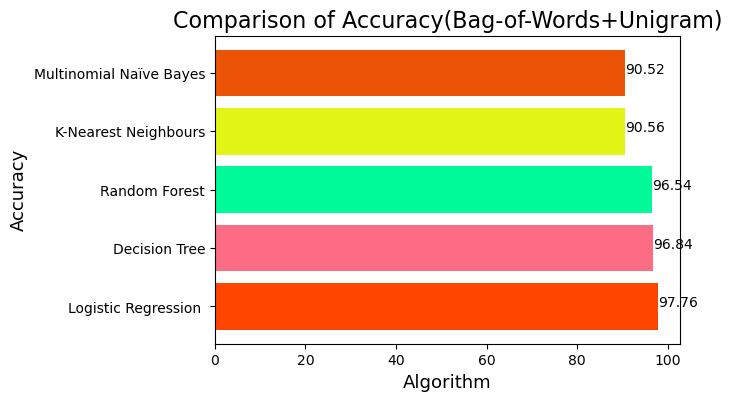

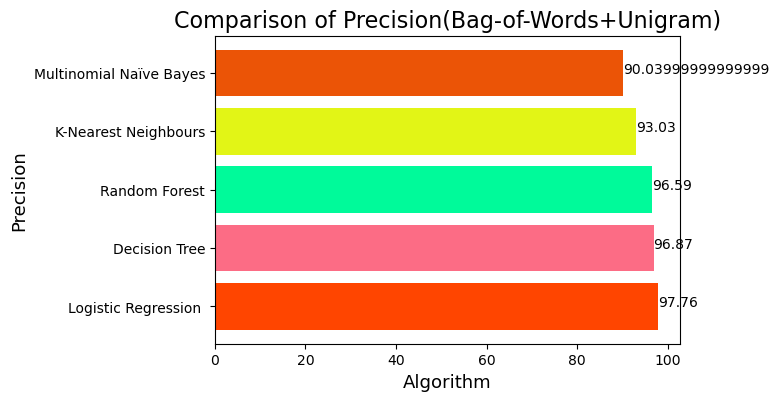

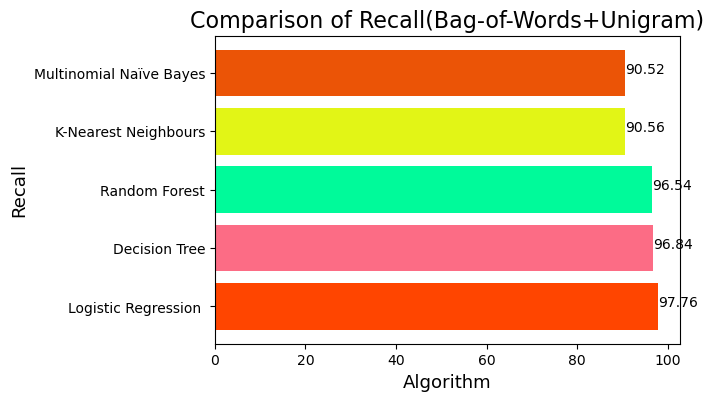

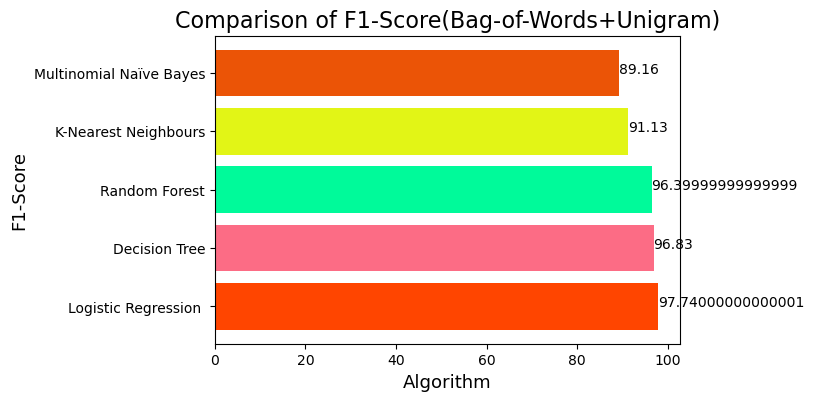

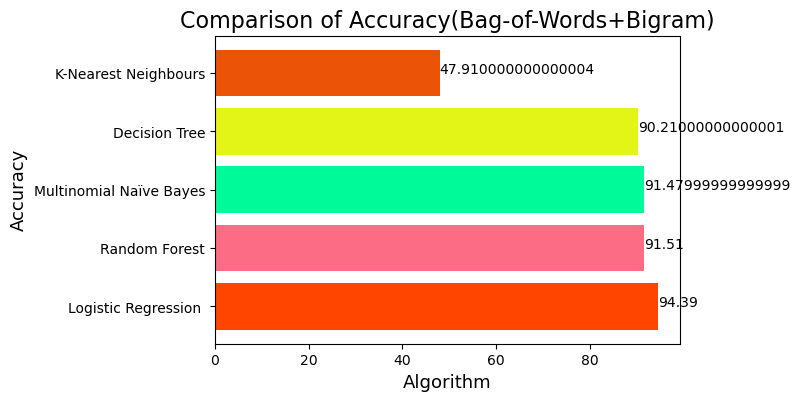

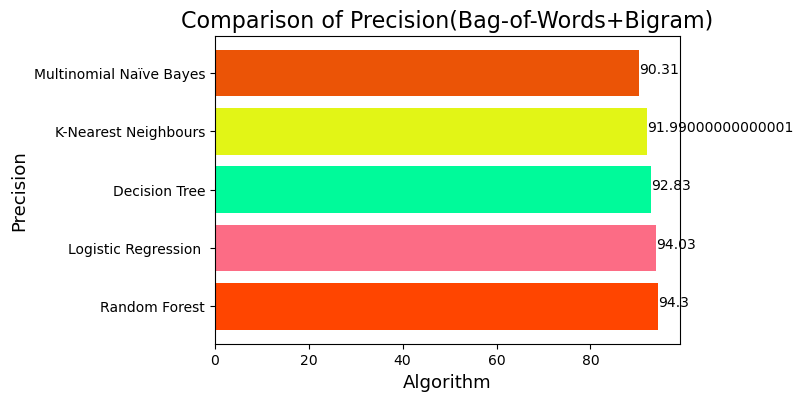

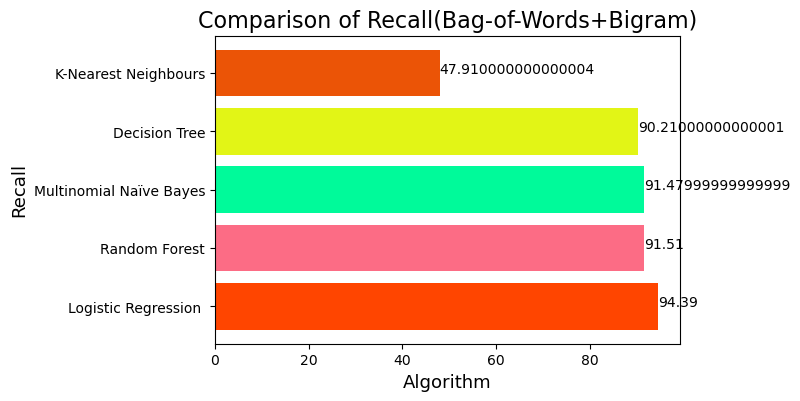

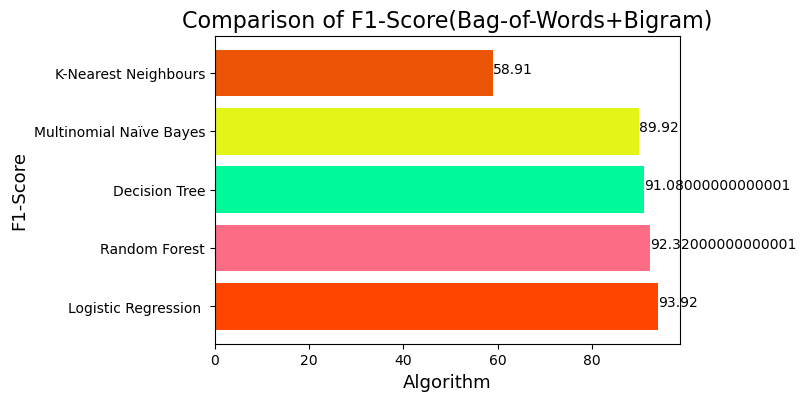

In [22]:
# Creating and displaying bar charts comparing model performance metrics using Bag-of-Words features, and save results to CSV files.

AllBOWDf=[]
for i in range(2):
    DfAmBOW=pa.DataFrame({
        "Algorithm":ClAmz,
        "Accuracy":ResMtBOWAmz[i][0],
        "Precision":ResMtBOWAmz[i][1],
        "Recall":ResMtBOWAmz[i][2],
        "F1-Score":ResMtBOWAmz[i][3]
    })
    AllBOWDf.append(DfAmBOW)
    plt_cols=DfAmBOW.columns.tolist()[1:]
    for x in plt_cols:
        DfAmBOW=DfAmBOW.sort_values(by=x,ascending=False)
        dfa_vs.figure(figsize=(6,4))
        dfa_vs.title("Comparison of {}(Bag-of-Words+{})".format(x,ngs_val[i]),fontsize=16)
        dfa_vs.barh(DfAmBOW['Algorithm'],DfAmBOW[x],color=["#FF4500","#FC6C85","#00FA9A","#E2F516","#EB5406"])
        dfa_vs.xlabel("Algorithm",fontsize=13)
        dfa_vs.ylabel("{}".format(x),fontsize=13)
        for BOWid, BOWvl in enumerate(DfAmBOW[x]):
            dfa_vs.text(BOWvl, BOWid, str(BOWvl))
        dfa_vs.show()
    DfAmBOW.sort_values(by="Accuracy",ascending=False).to_csv("{}_BOW.csv".format(ngs_val[i]))


In [23]:
AllBOWDf[0]

,Algorithm,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,97.76,97.76,97.76,97.74
1,Decision Tree,96.84,96.87,96.84,96.83
2,Multinomial Naïve Bayes,90.52,90.04,90.52,89.16
3,Random Forest,96.54,96.59,96.54,96.40
4,K-Nearest Neighbours,90.56,93.03,90.56,91.13


In [24]:
AllBOWDf[1]

,Algorithm,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,94.39,94.03,94.39,93.92
1,Decision Tree,90.21,92.83,90.21,91.08
2,Multinomial Naïve Bayes,91.48,90.31,91.48,89.92
3,Random Forest,91.51,94.30,91.51,92.32
4,K-Nearest Neighbours,47.91,91.99,47.91,58.91


## Determining Optimum Model

In [25]:
AlgTFIDF,AcrTFIDF=[],[]
for x in range(len(AllTFDf)):
    AlgTFIDF.append(AllTFDf[x].sort_values(by="Accuracy",ascending=False).iloc[0][0])
    AcrTFIDF.append(AllTFDf[x].sort_values(by="Accuracy",ascending=False).iloc[0][1])

AlgBOW,AcrBOW=[],[]
for x in range(len(AllBOWDf)):
    AlgBOW.append(AllBOWDf[0].sort_values(by="Accuracy",ascending=False).iloc[0][0])
    AcrBOW.append(AllBOWDf[x].sort_values(by="Accuracy",ascending=False).iloc[0][1])

AlgAll=[AlgTFIDF,AlgBOW] # the best algorithms from both TFIDF and Bag-of-Words
AcrAll=[AcrTFIDF,AcrBOW] # the best accuracies from both TFIDF and Bag-of-Words
vct=['TFIDF','Bag-of-Words'] # Defining the vectorization techniques
# Determine the optimum model and vectorization technique
for a in range(len(AlgAll)):
    if len(nu.unique(nu.array(AlgAll[a])))!=1:
        pass
    else:
        vl=AcrAll[a].index(max(AcrAll[a]))
        OptAcr=AcrAll[a][vl]
        OptAlg=AlgAll[a][vl]
        VctOpt=vct[a]
        NgOpt=ngs_val[vl]
# Print the optimum results
print("Optimum Model: {}\nAccuracy: {}%\nOptimum Vectorization Process: {}\nOptimum N-Gram: {}".format(OptAlg, OptAcr, VctOpt, NgOpt))

Optimum Model: Logistic Regression 
Accuracy: 97.76%
Optimum Vectorization Process: Bag-of-Words
Optimum N-Gram: Unigram


## Recommendation

In [26]:
FinMdl=MdAmz[ClAmz.index(OptAlg)]
print(FinMdl)
OptVectModel=text.CountVectorizer(stop_words='english', analyzer='word',max_df=0.7,ngram_range=(1,1))
TrComplete=OptVectModel.fit_transform(data['Review_Cleaned'])
FinMdl=FinMdl.fit(TrComplete, data['Sentiment'])
filename = 'Model_Recom.sav'   # Save the model for future use
pickle.dump(FinMdl, open(filename, 'wb'))

LogisticRegression()


In [27]:
MdlLoad = pickle.load(open(filename, 'rb'))   # load the model
print(MdlLoad)
OptVectModel=text.CountVectorizer(stop_words='english', analyzer='word',max_df=0.7,ngram_range=(1,1))
TrComplete=OptVectModel.fit_transform(data['Review_Cleaned'])  
PrdTrn=MdlLoad.predict(TrComplete)   

try:
    data['Predicted Sentiment']=PrdTrn
except:
    pass
data

LogisticRegression()


,Review,Review_Cleaned,categories,primaryCategories,imageURLs,reviews.rating,reviews.sourceURLs,Polarity,Sentiment,Predicted Sentiment
0,... 3 of them and one of the item is bad quali...,one item bad quality missing backup spring ord...,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,3,https://www.amazon.com/product-reviews/B00QWO9...,-0.450000,Negative,Negative
1,... always the less expensive way to go for pr...,always le expensive way go product like bulk a...,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,4,https://www.amazon.com/product-reviews/B00QWO9...,-0.500000,Negative,Negative
2,... are not Duracell but for the price i am ha...,duracell price happy well duracell price happy,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,5,https://www.amazon.com/product-reviews/B00QWO9...,0.800000,Positive,Positive
3,... as well as name brand batteries at a much ...,well name brand battery much better seem work ...,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,5,https://www.amazon.com/product-reviews/B00QWO9...,0.500000,Positive,Positive
4,... batteries are very long lasting the price ...,battery long lasting price great battery long ...,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,5,https://www.amazon.com/product-reviews/B00QWO9...,0.250000,Positive,Positive
...,...,...,...,...,...,...,...,...,...,...
28327,Xmas gift I got 2 of these for my 8 yr old twi...,xmas gift got yr old twin yr old one one bette...,"Fire Tablets,Tablets,All Tablets,Amazon Tablet...",Electronics,https://www.upccodesearch.com/images/barcode/0...,5,http://reviews.bestbuy.com/3545/5620410/review...,0.425000,Positive,Positive
28328,yes it is a great tablet. I bought this for my...,yes great tablet bought niece christmas gift y...,"Fire Tablets,Tablets,All Tablets,Amazon Tablet...",Electronics,https://www.upccodesearch.com/images/barcode/0...,4,http://reviews.bestbuy.com/3545/5620410/review...,0.466667,Positive,Positive
28329,You get a lot for the price! Very nice for lig...,get lot price nice light internet browsing kee...,"Fire Tablets,Tablets,All Tablets,Amazon Tablet...",Electronics,https://www.upccodesearch.com/images/barcode/0...,5,http://reviews.bestbuy.com/3545/5620410/review...,0.425000,Positive,Positive
28330,You get the entire World for less than $100! T...,get entire world le tablet absolutely everythi...,"Fire Tablets,Tablets,All Tablets,Amazon Tablet...",Electronics,https://www.upccodesearch.com/images/barcode/0...,5,http://reviews.bestbuy.com/3545/5620410/review...,0.312500,Positive,Positive


In [28]:
print("-------------------------------------------------------------")
print("---------------Amazon Product Recommendations----------------")
print("-------------------------------------------------------------")
InputUser=input("Enter Keyword (For Mutiple Keywords, use Comma): ")
InputUserlst=InputUser.split(",")
pcat=data['primaryCategories'].tolist() 

idx_keys=[]
for iu in range(len(InputUserlst)):
    for pc in range(len(pcat)):
        if InputUserlst[iu] in pcat[pc]:
            idx_keys.append(pc)
idx_keys=nu.unique(nu.array(idx_keys)).tolist()   
RecomAmazon=data.iloc[idx_keys]
print("Total {} Filtered for the Product Type: \n".format(len(RecomAmazon)),*InputUserlst,sep="\n")
RecomAmazon.head()

-------------------------------------------------------------
---------------Amazon Product Recommendations----------------
-------------------------------------------------------------
Enter Keyword (For Mutiple Keywords, use Comma): Health & Beauty
Total 12071 Filtered for the Product Type: 

Health & Beauty


,Review,Review_Cleaned,categories,primaryCategories,imageURLs,reviews.rating,reviews.sourceURLs,Polarity,Sentiment,Predicted Sentiment
0,... 3 of them and one of the item is bad quali...,one item bad quality missing backup spring ord...,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,3,https://www.amazon.com/product-reviews/B00QWO9...,-0.45,Negative,Negative
1,... always the less expensive way to go for pr...,always le expensive way go product like bulk a...,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,4,https://www.amazon.com/product-reviews/B00QWO9...,-0.50,Negative,Negative
2,... are not Duracell but for the price i am ha...,duracell price happy well duracell price happy,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,5,https://www.amazon.com/product-reviews/B00QWO9...,0.80,Positive,Positive
3,... as well as name brand batteries at a much ...,well name brand battery much better seem work ...,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,5,https://www.amazon.com/product-reviews/B00QWO9...,0.50,Positive,Positive
4,... batteries are very long lasting the price ...,battery long lasting price great battery long ...,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,5,https://www.amazon.com/product-reviews/B00QWO9...,0.25,Positive,Positive


In [29]:
A1=RecomAmazon[RecomAmazon['Predicted Sentiment']=="Positive"]
print("Total Data Selected Using Filter-1: {}".format(len(A1)))
A1.head()

Total Data Selected Using Filter-1: 9538


,Review,Review_Cleaned,categories,primaryCategories,imageURLs,reviews.rating,reviews.sourceURLs,Polarity,Sentiment,Predicted Sentiment
2,... are not Duracell but for the price i am ha...,duracell price happy well duracell price happy,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,5,https://www.amazon.com/product-reviews/B00QWO9...,0.800000,Positive,Positive
3,... as well as name brand batteries at a much ...,well name brand battery much better seem work ...,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,5,https://www.amazon.com/product-reviews/B00QWO9...,0.500000,Positive,Positive
4,... batteries are very long lasting the price ...,battery long lasting price great battery long ...,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,5,https://www.amazon.com/product-reviews/B00QWO9...,0.250000,Positive,Positive
5,... batteries for Christmas and the AmazonBasi...,battery christmas amazonbasics cell good haven...,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,5,https://www.amazon.com/product-reviews/B00QWO9...,0.466667,Positive,Positive
6,... batteries have ordered them in the past be...,battery ordered past pleased ive problame batt...,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,5,https://www.amazon.com/product-reviews/B00QWO9...,0.125000,Positive,Positive


In [30]:
A2=A1[A1['Polarity']>0.8]
print("Total Data Selected Using Filter-2: {}".format(len(A2)))
A2.head()

Total Data Selected Using Filter-2: 491


,Review,Review_Cleaned,categories,primaryCategories,imageURLs,reviews.rating,reviews.sourceURLs,Polarity,Sentiment,Predicted Sentiment
55,5 Stars Excellent,star excellent,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,5,https://www.amazon.com/product-reviews/B00QWO9...,1.0,Positive,Positive
72,A Christmas gift for my Grandson These worked ...,christmas gift grandson worked great battery p...,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,5,https://www.amazon.com/product-reviews/B00QWO9...,0.9,Positive,Positive
154,AA batts work perfectly! AA batteries worked p...,aa batts work perfectly aa battery worked perf...,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,5,https://www.amazon.com/product-reviews/B00QWO9...,1.0,Positive,Positive
162,AAA Alkaline Batteries A wonderful way to purc...,aaa alkaline battery wonderful way purchase,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,5,https://www.amazon.com/product-reviews/B00QWO9...,1.0,Positive,Positive
290,Amazon Tripple-A is top-notch product Perfectl...,amazon tripplea topnotch product perfectly sen...,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,5,https://www.amazon.com/product-reviews/B00QWO9...,1.0,Positive,Positive


In [31]:
A3=A2[A2['reviews.rating']>4.2]
print("Total Data Selected Using Filter-3: {}".format(len(A3)))
A3.head()

Total Data Selected Using Filter-3: 471


,Review,Review_Cleaned,categories,primaryCategories,imageURLs,reviews.rating,reviews.sourceURLs,Polarity,Sentiment,Predicted Sentiment
55,5 Stars Excellent,star excellent,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,5,https://www.amazon.com/product-reviews/B00QWO9...,1.0,Positive,Positive
72,A Christmas gift for my Grandson These worked ...,christmas gift grandson worked great battery p...,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,5,https://www.amazon.com/product-reviews/B00QWO9...,0.9,Positive,Positive
154,AA batts work perfectly! AA batteries worked p...,aa batts work perfectly aa battery worked perf...,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,5,https://www.amazon.com/product-reviews/B00QWO9...,1.0,Positive,Positive
162,AAA Alkaline Batteries A wonderful way to purc...,aaa alkaline battery wonderful way purchase,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,5,https://www.amazon.com/product-reviews/B00QWO9...,1.0,Positive,Positive
290,Amazon Tripple-A is top-notch product Perfectl...,amazon tripplea topnotch product perfectly sen...,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,5,https://www.amazon.com/product-reviews/B00QWO9...,1.0,Positive,Positive


In [32]:
RecomAmazon1=A3.reset_index(drop=True)
RecomAmazon2=RecomAmazon1.sort_values(by=["reviews.rating"],ascending=False).reset_index(drop=True)
RcAmTopFive=RecomAmazon2.drop_duplicates().iloc[:5]
RcAmTopFive

,Review,Review_Cleaned,categories,primaryCategories,imageURLs,reviews.rating,reviews.sourceURLs,Polarity,Sentiment,Predicted Sentiment
0,5 Stars Excellent,star excellent,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,5,https://www.amazon.com/product-reviews/B00QWO9...,1.000000,Positive,Positive
1,These are great Best place to buy batteries fo...,great best place buy battery great price,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,5,https://www.amazon.com/product-reviews/B00QWO9...,0.866667,Positive,Positive
2,"Worked perfectly, as described. Worked perfect...",worked perfectly described worked perfectly de...,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,5,https://www.amazon.com/product-reviews/B00QWO9...,1.000000,Positive,Positive
3,Work well. Cost less. I go through a lot of AA...,work well cost le go lot aa battery amazonbasi...,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,5,https://www.amazon.com/product-reviews/B00QWO9...,1.000000,Positive,Positive
4,Work Perfectly! They work just as well as any ...,work perfectly work well battery issue leak ba...,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,5,https://www.amazon.com/product-reviews/B00QWO9...,1.000000,Positive,Positive


In [33]:
racat=RcAmTopFive['categories'].tolist()
rapc=RcAmTopFive['primaryCategories'].tolist()
raim=RcAmTopFive['imageURLs'].tolist()
rarr=RcAmTopFive['reviews.rating'].tolist()
rapl=RcAmTopFive['Polarity'].tolist()

print("-------------------------------------------------------------")
print("-------------------------Top 5 Products----------------------")
print("-------------------------------------------------------------")

print("==========================================================================================================================")
print("==========================================================================================================================")
for tp5 in range(len(racat)):
    print("=================================================== Recommendation -{} ====================================================".format(tp5+1))
    print("==========================================================================================================================")
    print("\nPrimary Category: {}".format(rapc[tp5]))
    print("\nProduct Category: {}".format(' '.join(racat[tp5].split(",")[:4])))
    print("\nPolarity: {}".format(round(rapl[tp5],3)))
    print("\nRating: {}".format(rarr[tp5]))
    print("\nLinks: {}\n".format(raim[tp5]))
    print("==========================================================================================================================")
    print("==========================================================================================================================")

-------------------------------------------------------------
-------------------------Top 5 Products----------------------
-------------------------------------------------------------
=================================================== Recommendation -1 ====================================================

Primary Category: Health & Beauty

Product Category: AA AAA Health Electronics

Polarity: 1.0

Rating: 5

Links: https://images-na.ssl-images-amazon.com/images/I/81qmNyJo%2BkL._SL1500_.jpg,https://images-na.ssl-images-amazon.com/images/I/81ZTa1BrkzL._SL1500_.jpg,http://ecx.images-amazon.com/images/I/41pSoRu7UlL._SS40_.jpg,https://www.upccodesearch.com/images/barcode/0841710106442.png,https://images-na.ssl-images-amazon.com/images/I/81qmNyJo%252525252BkL._SL1500_.jpg,https://images-na.ssl-images-amazon.com/images/I/51DfBuqy4qL._SL1189_.jpg,https://images-na.ssl-images-amazon.com/images/I/51TshsEJTIL.jpg,https://images-na.ssl-images-amazon.com/images/I/81qmNyJo%2525252525252BkL._SL15